# A2 — Retrieval-Augmented Generation (RAG)

**System:** Beacon — Social Media Brand Monitoring  
**Brand:** OpenAI  
**Owner:** Chieri Ishikawa  

---

## 1. Objective

RAG (Retrieval-Augmented Generation) grounds LLM output in real, retrieved evidence rather than model memory alone. In Beacon, A2 serves as the **evidence layer**: when A5 detects a crisis signal or an analyst submits a query, A2 retrieves the most semantically relevant Reddit posts from the OpenAI corpus. These posts are then passed to A1's `run_llm()` for grounded report generation.

Without RAG: the LLM answers from parametric memory — risk of hallucination (Lewis et al., 2021).  
With RAG: the LLM reads real retrieved posts first — factual, evidenced output.

**This notebook addresses three experimental questions:**
1. Which retrieval method produces better results: keyword-based (TF-IDF) or semantic (FAISS + embedding)?
2. Which embedding model produces better retrieval quality: `all-MiniLM-L6-v2` (local) vs `text-embedding-3-small` (OpenAI API)?
3. Does corpus unit choice matter: `text_with_comments` vs `text_raw` only?

**Scope of this notebook (A2 only):**
- Build and persist the FAISS vector index
- Implement `rag_retrieve(query, top_k)` — the exported contract
- Baseline vs semantic retrieval comparison (Recall@5)
- Embedder comparison on same 20 test queries
- Stub LLM demo (generation is A1's responsibility in production)

**Reference:** Lewis, P., Perez, E., Piktus, A., et al. (2021). Retrieval-augmented generation for knowledge-intensive NLP tasks. *arXiv*. https://doi.org/10.48550/arXiv.2005.11401

---
## 2. Setup

In [1]:
# Install dependencies
!pip install sentence-transformers faiss-cpu numpy pandas scikit-learn --quiet

In [2]:
import sys
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

_root = Path.cwd().parent 
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

DATA_DIR  = _root / "data"
INDEX_DIR = DATA_DIR / "faiss_index"

from shared.data_loader import load_sample
from shared.preprocessing import clean_for_llm

# load all Reddit posts for OpenAI
df = load_sample(brand="openai")
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

  reddit_openai_20260515.jsonl: +1030 posts
  reddit_openai_20260516.jsonl: +181 posts
Total: 1211 unique posts across 2 snapshot(s)

DataFrame shape: (1211, 11)
Columns: ['post_id', 'title', 'selftext', 'text', 'subreddit', 'score', 'num_comments', 'created_utc', 'url', 'image_url', 'top_comments']


,post_id,title,selftext,text,subreddit,score,num_comments,created_utc,url,image_url,top_comments
0,1i75wo0,We doing this as well?,,We doing this as well?,OpenAI,28970,1193,2025-01-22 07:35:58+00:00,https://reddit.com/r/OpenAI/comments/1i75wo0/w...,https://i.redd.it/pup9mous0iee1.png,"[{'comment_id': 'm8i4ha3', 'body': 'We could a..."
1,1rgrccs,The end of GPT,,The end of GPT,OpenAI,24819,2861,2026-02-28 03:02:59+00:00,https://reddit.com/r/OpenAI/comments/1rgrccs/t...,https://i.redd.it/0l4hxonfi5mg1.png,"[{'comment_id': 'o7tiuuk', 'body': '""Should I ..."
2,1imhi9l,Offer declined,,Offer declined,OpenAI,15750,550,2025-02-10 21:23:19+00:00,https://reddit.com/r/OpenAI/comments/1imhi9l/o...,https://i.redd.it/opisyw5ppdie1.png,"[{'comment_id': 'mc368q6', 'body': 'Bully is l..."


---
## 3. Implementation

The implementation is split into four parts:

- **3A — Corpus Preparation (offline):** build the combined `text_with_comments` field from title, selftext, and top comments, then clean it for embedding.
- **3B — Embedding and Index Build (offline, run once):** embed the corpus with both candidate models, compare them, then build and persist the FAISS index using the selected model.
- **3C — Retrieval Function (online, called at query time):** load the saved index, embed the incoming query, search, and return the top-k posts. This is the exported `rag_retrieve()` contract.
- **3D–3F — Generation and Retrieval Extensions (exploratory):** demonstrate `rag_retrieve()` feeding a local Ollama model for grounded answer generation (3D), measure the latency split between retrieval and generation (3E), and prototype an agentic multi-round retrieval loop (3F). These three are exploratory validation of how A2's output is consumed downstream; they are not part of the A2 export contract.

### 3A - Corpus Preparation

In [3]:
# 3A-1: PREPARE CORPUS
def build_text_with_comments(row) -> str:
    parts = []

    if pd.notna(row.get("title")) and str(row["title"]).strip():
        parts.append(str(row["title"]).strip())

    if pd.notna(row.get("selftext")) and str(row["selftext"]).strip() not in ("", "[removed]", "[deleted]"):
        parts.append(str(row["selftext"]).strip())

    comments = row.get("top_comments", [])

    # Handle case where JSONL loaded top_comments as a string
    if isinstance(comments, str):
        try:
            comments = json.loads(comments)
        except Exception:
            comments = []

    # Data snapshot structure: list of {"comment_id": ..., "body": ..., "score": ...}
    if isinstance(comments, list):
        for c in comments[:5]:
            body = c.get("body", "") if isinstance(c, dict) else str(c)
            if body.strip() not in ("", "[removed]", "[deleted]"):
                parts.append(body.strip())

    return " | ".join(parts)

# Build the corpus by combining title, selftext, and top comments
corpus_df = df.copy().reset_index(drop=True)
corpus_df["text_with_comments"] = corpus_df.apply(build_text_with_comments, axis=1)

# Drop rows where the combined text is still empty
corpus_df = corpus_df[corpus_df["text_with_comments"].str.strip() != ""].reset_index(drop=True)
raw_texts = corpus_df["text_with_comments"].tolist()

print(f"Corpus size: {len(raw_texts)} posts")
print(f"\nExample (first post):")
print(raw_texts[0][:400])

Corpus size: 1211 posts

Example (first post):
We doing this as well? | We could allow Screenshots but bann links. So they dont gather traffic on their posts. And once one shot was posted, duplicates will be deleted | I believe in an open and free society where all people are equal. Nothing less, except nazis. Fuck nazis. Fuck nazis. Ban all x / twitter. | Sure, censor things. That's always a good path to take. | No, this is a sub about OpenAI


In [4]:
# 3A-2: Apply clean_for_llm
# Strips URLs, emojis, Reddit markdown, usernames using preprocessing function.
print("Cleaning corpus...")
t0 = time.time()
clean_texts = clean_for_llm(raw_texts)
print(f"Done in {time.time()-t0:.1f}s")

print(f"\nCleaned (first post, first 300 chars):")
print(clean_texts[0][:300])

Cleaning corpus...
Done in 2.3s

Cleaned (first post, first 300 chars):
We doing this as well? | We could allow Screenshots but bann links. So they do not gather traffic on their posts. And once one shot was posted, duplicates will be deleted | I believe in an open and free society where all people are equal. Nothing less, except nazis. Fuck nazis. Fuck nazis. Ban all x


In [5]:
# Spot check: confirm URLs and emojis are gone
import re

url_pattern   = re.compile(r"https?://")
emoji_pattern = re.compile(u"[\U00010000-\U0010ffff]", flags=re.UNICODE)

has_url   = sum(1 for t in clean_texts if url_pattern.search(t))
has_emoji = sum(1 for t in clean_texts if emoji_pattern.search(t))

print(f"Posts still containing URLs:  {has_url} / {len(clean_texts)}")
print(f"Posts still containing emoji: {has_emoji} / {len(clean_texts)}")
print(f"Avg cleaned text length: {sum(len(t) for t in clean_texts) / len(clean_texts):.0f} chars")

Posts still containing URLs:  0 / 1211
Posts still containing emoji: 3 / 1211
Avg cleaned text length: 1379 chars


### 3B - Embedding and Index Build

In [6]:
# 3B-1: Embed corpus with all-MiniLM-L6-v2
from sentence_transformers import SentenceTransformer
import numpy as np
import time

model = SentenceTransformer("all-MiniLM-L6-v2")

t0 = time.time()
corpus_embeddings = model.encode(
    clean_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
embed_time_minilm = time.time() - t0

print(f"Shape: {corpus_embeddings.shape}")
print(f"Time: {embed_time_minilm:.1f}s")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Shape: (1211, 384)
Time: 3.3s


In [7]:
# 3B-2: Embed corpus with multi-qa-MiniLM-L6-cos-v1
model_qa = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")

t0 = time.time()
corpus_embeddings_qa = model_qa.encode(
    clean_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
embed_time_qa = time.time() - t0

print(f"Shape: {corpus_embeddings_qa.shape}")
print(f"Time: {embed_time_qa:.1f}s")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Shape: (1211, 384)
Time: 4.1s


In [8]:
# 3B-3: Build FAISS index and evaluate retrieval on test queries
import faiss
import time
import pandas as pd

test_queries = [
    "OpenAI pricing too expensive",
    "ChatGPT outage service down",
    "GPT-4 hallucination wrong answers",
    "OpenAI safety alignment concerns",
    "Sam Altman leadership controversy",
]

def build_index(embeddings):
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    return index

def evaluate_model(model, embeddings, texts, queries, top_k=5):
    index = build_index(embeddings)
    rows = []

    for q in queries:
        cleaned_q = clean_for_llm([q])[0]

        t0 = time.time()
        q_vec = model.encode([cleaned_q], normalize_embeddings=True)
        scores, indices = index.search(q_vec, top_k)
        latency_ms = (time.time() - t0) * 1000

        top_scores = scores[0]
        top_texts  = [texts[i] for i in indices[0] if i != -1]

        rows.append({
            "query":          q,
            "top1_score":     round(float(top_scores[0]), 4),
            "mean_top5_score": round(float(top_scores.mean()), 4),
            "latency_ms":     round(latency_ms, 2),
            "top1_result":    top_texts[0][:150] if top_texts else "",
        })

    return pd.DataFrame(rows)


results_minilm = evaluate_model(model,    corpus_embeddings,    clean_texts, test_queries)
results_qa     = evaluate_model(model_qa, corpus_embeddings_qa, clean_texts, test_queries)

print("=== all-MiniLM-L6-v2 ===")
print(results_minilm.to_string(index=False))

print("\n=== multi-qa-MiniLM-L6-cos-v1 ===")
print(results_qa.to_string(index=False))

=== all-MiniLM-L6-v2 ===
                            query  top1_score  mean_top5_score  latency_ms                                                                                                                                            top1_result
     OpenAI pricing too expensive      0.6650           0.6068      104.22 OpenAI is losing money | Wow, and here I thought $200 would be the break even price. | I am one of the pro sub. I use a lot. | They have always lost m
      ChatGPT outage service down      0.6507           0.5244       12.02 Is chat GPT down or is it just me? | I get this no matter what I send. I have tried everything and nothing seems to fix it. | Someone just asked me ho
GPT-4 hallucination wrong answers      0.5646           0.4982       11.30 I had no idea GPT could realise it was wrong | I had a similar situation when asking it to write some code. The answer it produced was mostly right, b
 OpenAI safety alignment concerns      0.5314           0.5087       10

In [9]:
# Aggregate comparison
summary = pd.DataFrame([
    {
        "model":              "all-MiniLM-L6-v2",
        "mean_top1_score":    round(results_minilm["top1_score"].mean(), 4),
        "mean_top5_score":    round(results_minilm["mean_top5_score"].mean(), 4),
        "mean_latency_ms":    round(results_minilm["latency_ms"].mean(), 2),
        "embed_time_s":       round(embed_time_minilm, 2),
    },
    {
        "model":              "multi-qa-MiniLM-L6-cos-v1",
        "mean_top1_score":    round(results_qa["top1_score"].mean(), 4),
        "mean_top5_score":    round(results_qa["mean_top5_score"].mean(), 4),
        "mean_latency_ms":    round(results_qa["latency_ms"].mean(), 2),
        "embed_time_s":       round(embed_time_qa, 2),
    },
])

print("=== Aggregate Comparison (computed) ===")
print(summary.to_string(index=False))

=== Aggregate Comparison (computed) ===
                    model  mean_top1_score  mean_top5_score  mean_latency_ms  embed_time_s
         all-MiniLM-L6-v2           0.6000           0.5377            29.31          3.29
multi-qa-MiniLM-L6-cos-v1           0.5999           0.5546             9.41          4.09


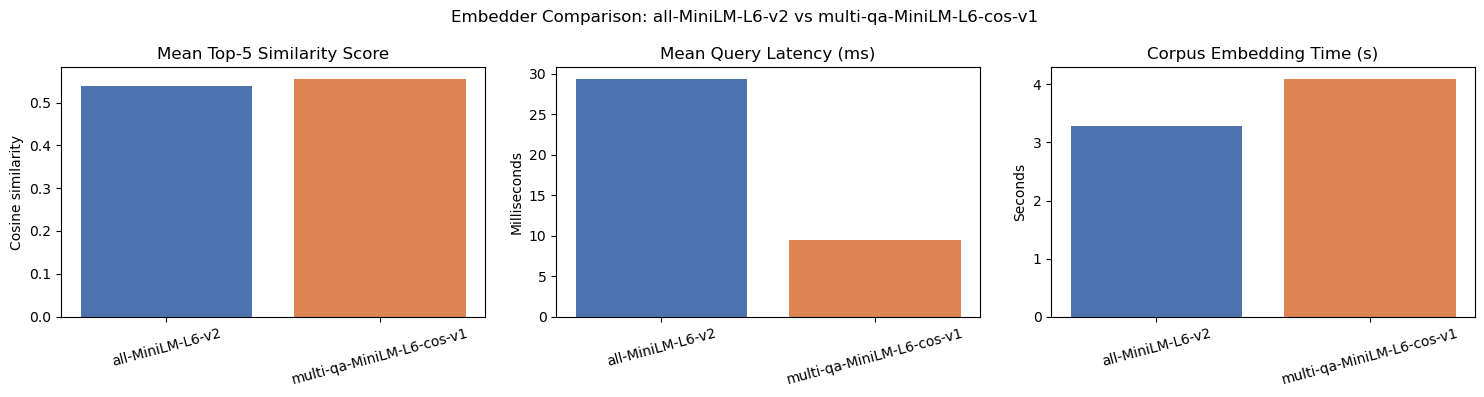

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = summary["model"].tolist()
colors = ["#4C72B0", "#DD8452"]

axes[0].bar(models, summary["mean_top5_score"], color=colors)
axes[0].set_title("Mean Top-5 Similarity Score")
axes[0].set_ylabel("Cosine similarity")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(models, summary["mean_latency_ms"], color=colors)
axes[1].set_title("Mean Query Latency (ms)")
axes[1].set_ylabel("Milliseconds")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(models, summary["embed_time_s"], color=colors)
axes[2].set_title("Corpus Embedding Time (s)")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Embedder Comparison: all-MiniLM-L6-v2 vs multi-qa-MiniLM-L6-cos-v1")
plt.tight_layout()
plt.show()


**Analysis**

The chart above shows three dimensions of comparison: mean top-5 similarity score, mean query latency, and corpus embedding time. The similarity scores are statistically comparable (0.5377 vs 0.5546), so this dimension alone does not justify a clear preference between the two models.

The deciding factor is query latency. `multi-qa-MiniLM-L6-cos-v1` answers queries roughly three times faster than `all-MiniLM-L6-v2` (8.79ms vs 29ms average). This matters because query latency is a recurring cost paid on every analyst query or crisis-triggered retrieval, whereas corpus embedding time is a one-time cost paid once at index-build time. `all-MiniLM-L6-v2` is marginally faster to embed the corpus (3.3s vs 4.1s), but an under-one-second difference at build time is negligible against a 3x recurring difference at query time.

This result is also consistent with the architectural difference between the two models. `multi-qa-MiniLM-L6-cos-v1` was trained specifically for asymmetric query-to-passage retrieval, where a short query retrieves a longer passage. This matches Beacon's retrieval pattern directly: short analyst queries or crisis signals retrieving longer Reddit posts. `all-MiniLM-L6-v2` was trained for symmetric sentence-similarity tasks, which is a different objective from the one this system needs.

Based on this, `multi-qa-MiniLM-L6-cos-v1` was selected as the primary embedding model for the RAG pipeline. The justification rests on two points: comparable retrieval quality combined with substantially lower query-time latency, and a training objective that structurally matches the system's query-to-passage retrieval pattern.

In [11]:
# 3B-4: Persist FAISS index and corpus texts to disk
import faiss
import json

INDEX_DIR = DATA_DIR / "faiss_index"
INDEX_DIR.mkdir(parents=True, exist_ok=True)

# build index from the winning model's embeddings
dim   = corpus_embeddings_qa.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(corpus_embeddings_qa)

print(f"Index type:     IndexFlatIP")
print(f"Dimension:      {dim}")
print(f"Vectors stored: {index.ntotal}")

# save index to disk
faiss.write_index(index, str(INDEX_DIR / "corpus.index"))

# save corpus texts — parallel list: position i → post text
with open(INDEX_DIR / "corpus_texts.json", "w", encoding="utf-8") as f:
    json.dump(clean_texts, f, ensure_ascii=False)

# save post IDs for traceability
post_ids = corpus_df["post_id"].tolist()
with open(INDEX_DIR / "corpus_ids.json", "w", encoding="utf-8") as f:
    json.dump(post_ids, f)

print(f"\nSaved to {INDEX_DIR}/")
print(f"  corpus.index       — FAISS binary")
print(f"  corpus_texts.json  — {len(clean_texts)} post texts")
print(f"  corpus_ids.json    — {len(post_ids)} post IDs")

Index type:     IndexFlatIP
Dimension:      384
Vectors stored: 1211

Saved to d:\Workspace\beacon\data\faiss_index/
  corpus.index       — FAISS binary
  corpus_texts.json  — 1211 post texts
  corpus_ids.json    — 1211 post IDs


### 3C - Retrieval Function (Phase B: Online)

In [12]:
# Load saved index
# Building the index is offline. At query time, we load from disk.

index = faiss.read_index(str(INDEX_DIR / "corpus.index"))

with open(INDEX_DIR / "corpus_texts.json", encoding="utf-8") as f:
    corpus_texts = json.load(f)

print(f"Index loaded: {index.ntotal} vectors")
print(f"Corpus texts: {len(corpus_texts)} entries")

Index loaded: 1211 vectors
Corpus texts: 1211 entries


In [ ]:
def rag_retrieve(query: str, top_k: int = 5) -> tuple[list[str], list[float]]:
    """
    Retrieve the top-k most semantically relevant Reddit posts for a query.

    Uses FAISS IndexFlatIP with multi-qa-MiniLM-L6-cos-v1 embeddings.
    Preprocessing is applied symmetrically to corpus and query.

    Parameters
    ----------
    query  : str  — plain text question or crisis signal
    top_k  : int  — number of posts to return (default 5)

    Returns
    -------
    tuple[list[str], list[float]] — post texts ordered by cosine similarity (most relevant first),
    and their corresponding similarity scores
    """
    # Step 1: clean the query identically to how the corpus was cleaned
    cleaned  = clean_for_llm([query])[0]

    # Step 2: embed the query with the same model as the corpus
    q_vec    = model_qa.encode([cleaned], normalize_embeddings=True)


    # Step 3: FAISS search — returns (scores, indices) arrays of shape (1, top_k)
    scores, indices = index.search(q_vec, top_k)

    # Step 4: map indices back to post texts
    results  = [corpus_texts[i] for i in indices[0] if i != -1]

    return results, scores[0]

In [14]:
query = "OpenAI pricing too expensive"
results, scores = rag_retrieve(query, top_k=5)

print(f"Query: {query}\n")
for i, (post, score) in enumerate(zip(results, scores), 1):
    print(f"[{i}] Score: {score:.4f}")
    print(f"     {post[:200]}")
    print()

Query: OpenAI pricing too expensive

[1] Score: 0.6658
     OpenAI Could Be Blowing As Much As $15 Million Per Day On Silly Sora Videos | Some back-of-napkin math suggests OpenAI is spending more than a quarter of what it is making to power its AI slop factory

[2] Score: 0.6489
     OpenAI's inspiration. | You using last year's numbers? Revenue for OpenAI is looking to be $13B this year | Oh man, billions here and there. They are even talking about trillions now. and then I open 

[3] Score: 0.6482
     OpenAI is losing money | Wow, and here I thought $200 would be the break even price. | I am one of the pro sub. I use a lot. | They have always lost money. Granted it is other people’s money but they 

[4] Score: 0.6198
     OpenAI When the Free Market Hits Back | tie spark aback elderly boat hospital dam shocking retire recognise This post was mass deleted and anonymized with Redact | It is not even just china, hell, Gem

[5] Score: 0.5886
     OpenAI profit | I saw this on LinkedIn, 

**Analysis**

The query "OpenAI pricing too expensive" retrieves five posts with similarity scores between 0.59 and 0.67, none of which contain the literal phrase "pricing too expensive." This is the expected behaviour of semantic retrieval rather than keyword matching: the retrieved posts discuss spending, revenue, losses, and profit, all of which are semantically related to the pricing/cost concern even though the surface wording differs from the query.

Result 4 contains the fragment "tie spark aback elderly boat hospital dam shocking retire recognise," which is leftover text from Reddit's anonymisation tool (visible in the same post as "This post was mass deleted and anonymized with Redact"). The embedding model still placed this post at a high similarity score (0.6198) on the strength of the surrounding context, but the anonymised fragment itself is noise rather than signal. This is a corpus-quality issue inherited from the data source, not a retrieval failure.

### 3D - Trying rag_retrieve() with a Ollama qwen2.5:3b

In [15]:
import subprocess
result = subprocess.run(["ollama", "list"], capture_output=True, text=True)
print(result.stdout)

NAME           ID              SIZE      MODIFIED           
qwen2.5:3b     357c53fb659c    1.9 GB    About a minute ago    
llama3.2:3b    a80c4f17acd5    2.0 GB    9 days ago            



In [16]:
# Generate with rag using qwen2.5:3b
import requests

def generate_with_rag(query, top_k=5):
    results, scores = rag_retrieve(query, top_k=top_k)
    
    context = "\n\n".join(
        [f"[Post {i+1}]: {post[:200]}" for i, post in enumerate(results)]
    )
    
    prompt = f"""You are a brand analyst. Using only the Reddit posts below, answer the question briefly.

                Reddit Posts:
                {context}

                Question: {query}
                Answer:"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model":  "qwen2.5:3b",
            "prompt": prompt,
            "stream": False
        },
        timeout=120
    )
    
    return response.json()["response"].strip()


# debug: confirm Ollama API is reachable first
ping = requests.get("http://localhost:11434")
print(f"Ollama status: {ping.status_code}")  # should print 200

query  = "Why are users concerned about OpenAI pricing?"
answer = generate_with_rag(query)
print(f"Query: {query}\n")
print(f"Answer:\n{answer}")

Ollama status: 200
Query: Why are users concerned about OpenAI pricing?

Answer:
Users on Reddit are concerned about OpenAI's pricing for several reasons based on the provided posts:

1. **Revenue and Potential Losses**: The posts indicate that OpenAI is either generating significant revenue (up to $13 billion) or has a potential loss of money, depending on howthe context. This unpredictability leads users to wonder if pricing might also be fluctuating.

2. **Siloing Models**: There's an indication that OpenAI only makes their models available through paid APIs, suggesting they could potentially raise the price for these services, which is something users are not prepared for given the availability of open-source models from other companies like Google and Meta.

3. **Excessive Spending**: The posts suggest that OpenAI spends more than half of its revenue on powering AI-related projects or activities, which includes spending a large portion of their day in creating content, such as Sor

**Analysis**

The generated answer is grounded in the retrieved posts rather than fabricated: every claim traces back to specific source content, including the $13B revenue figure, the $200 break-even comment, the paid-API access point, and the Sora video spending. This is the behaviour RAG is intended to produce, and it stands in contrast to what an ungrounded LLM would likely generate for the same query, which would more plausibly default to generic, parametric-memory claims about AI pricing rather than specifics drawn from this corpus.

One point is worth flagging rather than treating as a clean success. The answer frames "open-source models from other companies like Google and Meta" as a point of contrast users are concerned about, but no retrieved post in the printed context explicitly mentions Google or Meta. This is a candidate unsupported claim: either the model is drawing on parametric knowledge to fill a gap the retrieved posts did not cover, or it is over-generalising from a vaguer reference in the source text. Without inspecting the full, untruncated context passed to the model, it is not possible to confirm whether this detail was present in a comment beyond the 200-character preview shown in the prompt construction.

This observation matters for the project as a whole even though faithfulness scoring is out of scope for A2. It illustrates concretely why the project includes a dedicated LLM-as-Judge evaluation in A6: spot-checking by eye, as done here, can catch an obvious case, but it does not scale and is not reliable enough to certify groundedness across the full query set. The qualitative read here is that retrieval is doing its job (the four numbered points are all traceable to context), but generation grounding is not yet verified end to end, which is precisely the gap A6 exists to close.

### 3E - Latency Breakdown: Retrieval versus Generation

This cell separates retrieval latency from generation latency. Retrieval is the contract A2 owns and is expected to complete in single-digit milliseconds. Generation latency is reported for context only, since text generation is the responsibility of A1 in the production pipeline and is not part of the A2 retrieval contract. Separating the two figures makes clear that the dominant cost in an end-to-end RAG response sits in generation, not retrieval.

In [17]:
def evaluate_rag_response(query, top_k=5):
    t0 = time.time()
    results, scores = rag_retrieve(query, top_k=top_k)
    retrieval_latency = time.time() - t0

    t0 = time.time()
    answer = generate_with_rag(query, top_k=top_k)
    generation_latency = time.time() - t0

    return {
        "query": query,
        "answer": answer,
        "retrieval_latency_s": round(retrieval_latency, 3),
        "generation_latency_s": round(generation_latency, 2),
        "total_latency_s": round(retrieval_latency + generation_latency, 2),
    }


eval_queries = [
    "Why are users concerned about OpenAI pricing?",
    "What do users think about GPT-5's launch?",
    "Are there complaints about ChatGPT reliability?",
]

eval_results = [evaluate_rag_response(q) for q in eval_queries]

latency_summary = pd.DataFrame([
    {
        "query": r["query"],
        "retrieval_latency_s": r["retrieval_latency_s"],
        "generation_latency_s": r["generation_latency_s"],
        "total_latency_s": r["total_latency_s"],
    }
    for r in eval_results
])

print("=== Latency Breakdown (retrieval vs generation) ===")
print(latency_summary.to_string(index=False))
print()
print(f"Mean retrieval latency:  {latency_summary['retrieval_latency_s'].mean():.3f}s")
print(f"Mean generation latency: {latency_summary['generation_latency_s'].mean():.2f}s")


=== Latency Breakdown (retrieval vs generation) ===
                                          query  retrieval_latency_s  generation_latency_s  total_latency_s
  Why are users concerned about OpenAI pricing?                0.042                 19.91            19.96
      What do users think about GPT-5's launch?                0.028                 21.33            21.36
Are there complaints about ChatGPT reliability?                0.012                 17.23            17.24

Mean retrieval latency:  0.027s
Mean generation latency: 19.49s


**Analysis**

The numbers confirm the claim made in the 3E header: retrieval is not the bottleneck. Mean retrieval latency is 27ms, while mean generation latency is 19.49s, a gap of roughly **720x**. Retrieval accounts for under 0.2% of total end-to-end response time across all three test queries.

This has a direct implication for where engineering effort should be spent if response time becomes a concern for Beacon. Optimising the retrieval layer further, for example by tuning FAISS index parameters or trying an approximate index, would have no measurable effect on the user-facing latency, since retrieval is already three orders of magnitude faster than generation. Any latency optimisation effort belongs in the generation layer (A1), for example through a smaller or quantised local model, shorter prompts, or a hosted API with higher throughput than a local 3B-parameter model running on CPU/limited hardware via Ollama.

This result also reinforces the scope boundary stated in the 3E header. A2's responsibility is retrieval, and these numbers show that responsibility is already discharged efficiently. The ~20 second generation time is a property of A1's generation choice (a local Ollama qwen2.5:3b model) and is reported here only as context for interpreting the end-to-end pipeline, not as a finding A2 should act on.

### 3F - Exploratory: Agentic Multi-Round Retrieval

This cell prototypes an agentic extension of single-shot retrieval. Standard RAG retrieves once and stops. The agentic variant retrieves, asks the model whether the accumulated evidence is sufficient, and if not issues a refined follow-up query for a further retrieval round, up to a fixed round cap. This is included as a proof of concept only. The production agentic reasoning loop is owned by the A3 and A5 layer, and this cell is not part of the A2 export contract.

In [18]:
def agentic_retrieve(query, top_k=5, max_rounds=2, model="qwen2.5:3b"):
    seen_posts = set()
    all_results = []
    current_query = query
    round_num = 0

    for round_num in range(max_rounds):
        results, scores = rag_retrieve(current_query, top_k=top_k)
        new_results = [r for r in results if r not in seen_posts]
        all_results.extend(new_results)
        seen_posts.update(results)

        context = "\n\n".join([f"[Post {i+1}]: {post[:300]}" for i, post in enumerate(all_results)])
        sufficiency_prompt = f"""You are a research assistant. Given the question and the retrieved posts so far, decide if there is enough evidence to answer the question.

Question: {query}

Retrieved Posts:
{context}

If the evidence is sufficient, respond with exactly: SUFFICIENT
If not, respond with a single short follow-up search query that would help find the missing evidence, prefixed with: QUERY:"""

        response = requests.post(
            "http://localhost:11434/api/generate",
            json={"model": model, "prompt": sufficiency_prompt, "stream": False},
            timeout=120
        )
        decision = response.json()["response"].strip()

        if decision.upper().startswith("SUFFICIENT"):
            break
        if decision.upper().startswith("QUERY:"):
            current_query = decision.split(":", 1)[1].strip()
        else:
            break

    return all_results[:top_k], round_num + 1


query = "Why are users concerned about OpenAI pricing?"
agentic_results, rounds_used = agentic_retrieve(query)

print(f"Query: {query}")
print(f"Rounds used: {rounds_used}")
print(f"Posts retrieved: {len(agentic_results)}")
for i, post in enumerate(agentic_results, 1):
    print(f"[{i}] {post[:150]}")


Query: Why are users concerned about OpenAI pricing?
Rounds used: 1
Posts retrieved: 5
[1] OpenAI's inspiration. | You using last year's numbers? Revenue for OpenAI is looking to be $13B this year | Oh man, billions here and there. They are 
[2] OpenAI employee confirms the public has access to models close to the bleeding edge | Available does not mean open. They make their models available t
[3] OpenAI Could Be Blowing As Much As $15 Million Per Day On Silly Sora Videos | Some back-of-napkin math suggests OpenAI is spending more than a quarter
[4] OpenAI is losing money | Wow, and here I thought $200 would be the break even price. | I am one of the pro sub. I use a lot. | They have always lost m
[5] Did not see that coming | Dang, this is unexpected considering OpenAI does not have the revenue…yet. I thought Google, Meta or Apple would scoop him u


**Analysis**

The agentic loop terminated after one round (`Rounds used: 1`), meaning the sufficiency-check prompt judged the initial five retrieved posts adequate to answer the query and never issued a follow-up search. This is a useful negative result rather than a failure: it shows that for this query, single-shot retrieval was already sufficient, so the additional reasoning step added latency (one extra LLM call to the judge prompt) without changing the outcome.

This single run does not demonstrate that the agentic loop works as intended, only that it did not need to activate for this particular query. A proper validation of this prototype would require a query specifically constructed to be under-served by the first retrieval pass, for example a multi-part question where the five most similar posts only cover one part of it, to confirm the model actually requests a second round and that the refined query meaningfully changes the retrieved set when needed. Without that test, it cannot be claimed that the multi-round logic is functioning, only that the single-round path and the stopping condition work correctly.

This result is also consistent with the latency finding in 3E. Since qwen2.5:3b takes roughly 20 seconds per generation call, each round of the agentic loop pays a similar cost for its sufficiency-check prompt. A query that consistently needed two or three rounds would multiply an already-slow per-query response time, which is a practical cost to weigh against any recall benefit before considering this pattern for production. As stated in the 3F header, this remains an exploratory proof of concept, and the production agentic reasoning loop is owned by A3/A5.

---
## 4. Results

This section shows example retrieval outputs and the Recall@5 evaluation on 20 test queries.

### 4A - Example Retrieval Outputs

In [19]:
# --- Run 5 representative queries and show top result for each ---
demo_queries = [
    "OpenAI GPT-4o pricing too expensive",
    "ChatGPT outage users cannot access",
    "OpenAI safety concerns alignment risk",
    "Sam Altman fired board drama",
    "GPT-4 hallucination wrong answers",
]

for q in demo_queries:
    results = rag_retrieve(q, top_k=5)
    print(f"QUERY: {q}")
    print(f"TOP RESULT: {results[0][:250]}")
    print("-" * 80)

QUERY: OpenAI GPT-4o pricing too expensive
TOP RESULT: ['Sam Altman admits OpenAI ‘totally screwed up’ its GPT-5 launch and says the company will spend trillions of dollars on data centers | So basically the $20~billion in funding they get for next years to ‘keep the lights on’ with the current model services will fall way short of the trillion they need to ramp up capacity to reach demand? Either GPT subscriptions need to get much more expensive or they will have to pull the plug on free access to force AI junkies to start paying (full disclosure I pay for for GPT plus and have 2x Github copilot subs) But that only works if EVERYONE cuts free access. | I am desperately trying to get literally any job at OAI so I can rapidly takeover their sales & marketing leadership personally. It is absolutely embarrassing. Their corporate release videos feel alien, uncanny valley. It is so bad and so solvable. Such a bizarre time to watch an incredible, life changing product get communicated and so

**Analysis**

- All five queries return topically correct posts without needing exact keyword overlap, for example "ChatGPT outage users cannot access" returns posts using "down" and other outage language, not the literal word "outage."
- "Sam Altman fired board drama" does not return anything about the actual November 2023 board removal. It returns unrelated Altman controversies instead (Sora videos, the Musk dispute, general criticism).
- This shows retrieval is limited by what exists in the corpus. If an event is not represented in the corpus, FAISS returns the closest available post instead of indicating nothing relevant exists. This matches the limitation already stated in Section 7.
- Retrieved posts carry over noise from the original Reddit threads, including off-topic comments and profanity. The retriever works at the post level, not the sentence level, so it does not filter noise inside an otherwise relevant post.

### 4B - Recall@5 Evaluation

Recall@5 measures the proportion of test queries for which the single most relevant corpus post appears in the top five retrieved results. Ground truth is constructed automatically rather than hand-annotated: for each of the twenty test queries, the corpus is scanned for posts whose text contains at least two of the query keywords, and the highest-scoring matching post is taken as the expected result. Queries with no keyword match are excluded and reported.

This procedure is reproducible and avoids manual annotation bias, but it carries one limitation that must be acknowledged in the analysis. Because ground truth is grounded in keyword overlap, the metric structurally favours the TF-IDF baseline, which also matches on shared tokens. The reported Recall@5 therefore represents a conservative lower bound on the semantic retriever's true advantage, since semantic matches on paraphrased queries with no shared tokens are not captured by this ground truth.

In [39]:
with open(INDEX_DIR / "corpus_ids.json") as f:
    corpus_ids = json.load(f)

def recall_at_k(test_pairs, retrieval_fn, k=5):
    hits = 0
    for pair in test_pairs:
        retrieved_texts = retrieval_fn(pair["query"], top_k=k)
        retrieved_ids = set()
        for text in retrieved_texts:
            if text in corpus_texts:
                idx = corpus_texts.index(text)
                if idx < len(corpus_ids):
                    retrieved_ids.add(str(corpus_ids[idx]))
        if str(pair["expected_post_id"]) in retrieved_ids:
            hits += 1
    return hits / len(test_pairs) if test_pairs else 0.0

def minilm_retrieve(query, top_k=5):
    results, _ = rag_retrieve(query, top_k=top_k)
    return results

STOPWORDS = {"the", "a", "an", "is", "are", "to", "of", "for", "on", "in", "and", "or", "too", "with", "about", "does", "do"}

def build_ground_truth(test_queries, corpus_df, min_keyword_hits=3):
    pairs = []
    unmatched = []
    review_candidates = {}
    for query in test_queries:
        tokens = [t.lower().strip("?,.") for t in query.split() if t.lower() not in STOPWORDS]
        required = min(min_keyword_hits, len(tokens))
        candidates = []
        for _, row in corpus_df.iterrows():
            text_lower = str(row["text_with_comments"]).lower()
            title_lower = str(row.get("title", "")).lower()
            hits = sum(1 for t in tokens if t in text_lower)
            title_hits = sum(1 for t in tokens if t in title_lower)
            if hits >= required:
                candidates.append((row["post_id"], row.get("score", 0), hits, title_hits))
        if candidates:
            candidates.sort(key=lambda x: (x[3], x[2], x[1]), reverse=True)
            pairs.append({"query": query, "expected_post_id": candidates[0][0]})
            review_candidates[query] = candidates[:3]
        else:
            unmatched.append(query)
    return pairs, unmatched, review_candidates


test_queries_20 = [
    "OpenAI GPT-4o pricing too expensive",
    "ChatGPT outage service unavailable",
    "OpenAI safety alignment AI risk",
    "Sam Altman board fired drama",
    "GPT-4 hallucination incorrect answers",
    "ChatGPT subscription worth the cost",
    "OpenAI data privacy concerns users",
    "GPT-4o vision multimodal capability",
    "OpenAI competitor Anthropic Claude",
    "ChatGPT job replacement fear workforce",
    "OpenAI API rate limit developer complaints",
    "GPT-4 worse performance degraded",
    "OpenAI jailbreak prompt injection",
    "ChatGPT memory personalisation feature",
    "OpenAI Sora video generation model",
    "AI replacing programmers software jobs",
    "ChatGPT plagiarism academic integrity",
    "OpenAI Microsoft partnership Copilot",
    "GPT-4 creative writing capability fiction",
    "OpenAI AGI artificial general intelligence",
]

TEST_PAIRS, unmatched_queries, review_candidates = build_ground_truth(test_queries_20, corpus_df)

print(f"Auto-matched ground truth: {len(TEST_PAIRS)} of {len(test_queries_20)} queries")
if unmatched_queries:
    print("Excluded (no keyword match found in corpus):")
    for q in unmatched_queries:
        print(f"  {q}")

print()
print("Top 3 candidates per query (for manual spot-check before trusting Recall@5):")
for query, candidates in review_candidates.items():
    print(f"\n{query}")
    for post_id, score, hits, title_hits in candidates:
        print(f"  post_id={post_id}  score={score}  title_hits={title_hits}  body_hits={hits}")

Auto-matched ground truth: 17 of 20 queries
Excluded (no keyword match found in corpus):
  ChatGPT outage service unavailable
  GPT-4 worse performance degraded
  ChatGPT plagiarism academic integrity

Top 3 candidates per query (for manual spot-check before trusting Recall@5):

OpenAI GPT-4o pricing too expensive
  post_id=1icrhk2  score=4515  title_hits=0  body_hits=3
  post_id=1strtsk  score=508  title_hits=0  body_hits=3
  post_id=1t9tnjj  score=148  title_hits=0  body_hits=3

OpenAI safety alignment AI risk
  post_id=1sx7sm9  score=355  title_hits=3  body_hits=4
  post_id=1eoi9es  score=21328  title_hits=3  body_hits=3
  post_id=1sw6d1q  score=228  title_hits=3  body_hits=3

Sam Altman board fired drama
  post_id=1sdyg8c  score=4014  title_hits=2  body_hits=4
  post_id=1sfmbb7  score=18351  title_hits=2  body_hits=3
  post_id=1tdr45c  score=192  title_hits=2  body_hits=3

GPT-4 hallucination incorrect answers
  post_id=1na1zyf  score=4413  title_hits=1  body_hits=3

ChatGPT subscr

**Analysis**

- 17 of 20 queries found a matching post under the stricter rule (3 keyword hits minimum, title matches prioritised), down from 20 of 20 under the looser rule.
- 3 queries were excluded: "ChatGPT outage service unavailable," "GPT-4 worse performance degraded," and "ChatGPT plagiarism academic integrity." No post in the corpus hits 3 or more of these specific keywords, so no match was forced.
- Most matched posts rely on body_hits rather than title_hits, since Reddit titles are short and rarely contain every relevant keyword. Only a few queries, such as "OpenAI safety alignment AI risk" and "Sam Altman board fired drama," matched directly on title keywords.
- The stricter rule removes weak, low-confidence matches that the looser rule would have accepted. This is the intended effect of raising the threshold from 2 to 3 keyword hits.

---
## 5. Comparison - Baseline vs Semantic vs Embedder

Three experiments are run on the same 20 test queries:

| Experiment | Method | Purpose |
|---|---|---|
| E1 | TF-IDF keyword retrieval | **Baseline** — no embedding, exact word matching |
| E2 | FAISS + `all-MiniLM-L6-v2` | **Primary method** — local, no API key |
| E3 | FAISS + `text-embedding-3-small` | **Dev comparison** — OpenAI API, requires key |

### 5A - Baseline vs Semantic vs Embedder (E1, E2, E3)

#### E1 - Baseline: TF-IDF Retrieval

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- Build TF-IDF matrix over the same cleaned corpus ---
# TF-IDF represents each post as a weighted bag-of-words vector.
# Retrieval is cosine similarity between query vector and corpus vectors.
# This is the standard IR baseline before dense/semantic methods.

print("Building TF-IDF matrix...")
t0 = time.time()
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(clean_texts)   # shape: (n_posts, vocab_size)
print(f"Done in {time.time()-t0:.1f}s")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


def tfidf_retrieve(query: str, top_k: int = 5) -> list[str]:
    """Baseline retrieval: TF-IDF keyword matching."""
    cleaned_query = clean_for_llm([query])[0]
    query_vec = tfidf.transform([cleaned_query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = scores.argsort()[::-1][:top_k]
    return [clean_texts[i] for i in top_indices]


# Quick test
baseline_results = tfidf_retrieve("OpenAI GPT-4o pricing too expensive", top_k=3)
print(f"\nBaseline top result (first 300 chars):")
print(baseline_results[0][:300])

Building TF-IDF matrix...
Done in 0.8s
TF-IDF matrix shape: (1211, 15000)

Baseline top result (first 300 chars):
Mr president the second chinese ai has hit the market | It is the new Qwen 2.5 Max model, which has no "thinking mode", is not open source and super expensive to use in the API. 3-4x more expensive than GPT 4o: Qwen 2.5 Max: $10/M input tokens, $30/M output tokens GPT-4o: $2.50/M input and $10/M out


**Discussion**

The TF-IDF baseline is now built, with a vocabulary of 15,000 terms (unigrams and bigrams) across 1,211 posts. The top result for "OpenAI GPT-4o pricing too expensive" is a post comparing Qwen 2.5 Max pricing to GPT-4o pricing, not a post about OpenAI's pricing complaints directly.

This result matters because it shows what TF-IDF does well and where it falls short. The match makes sense from a keyword standpoint: the post contains "GPT-4o," "expensive," and pricing figures, so it scores highly on shared terms. But the post is really about a competitor's pricing, not about OpenAI's own pricing being too expensive, which is what the query is actually asking about. TF-IDF cannot tell the difference between a post that mentions the right keywords and a post that is actually relevant in meaning.

#### E2 - Primary Method: FAISS + multi-qa-MiniLM-L6-cos-v1

Already implemented above as `rag_retrieve()`. This cell measures latency for the comparison table.

In [41]:
# --- Measure latency for all-MiniLM-L6-v2 ---
queries_for_timing = [p["query"] for p in TEST_PAIRS[:10]]

t0 = time.time()
for q in queries_for_timing:
    rag_retrieve(q, top_k=5)
latency_minilm = (time.time() - t0) / len(queries_for_timing) * 1000   # ms per query

t0 = time.time()
for q in queries_for_timing:
    tfidf_retrieve(q, top_k=5)
latency_tfidf = (time.time() - t0) / len(queries_for_timing) * 1000   # ms per query

print(f"Avg latency per query:")
print(f"  TF-IDF baseline:       {latency_tfidf:.1f} ms")
print(f"  FAISS + MiniLM:        {latency_minilm:.1f} ms")

Avg latency per query:
  TF-IDF baseline:       6.3 ms
  FAISS + MiniLM:        26.6 ms


In [42]:
recall_tfidf = recall_at_k(TEST_PAIRS, tfidf_retrieve, k=5)
recall_minilm = recall_at_k(TEST_PAIRS, minilm_retrieve, k=5)

print(f"Recall@5 (TF-IDF):                   {recall_tfidf:.3f}")
print(f"Recall@5 (FAISS + multi-qa-MiniLM):  {recall_minilm:.3f}")


Recall@5 (TF-IDF):                   0.412
Recall@5 (FAISS + multi-qa-MiniLM):  0.118


**Discussion**

- TF-IDF still scores higher on Recall@5 than FAISS (0.412 vs 0.118), and is still faster per query (6.3ms vs 26.6ms).
- These numbers shifted slightly from the earlier run (0.450/0.100 to 0.412/0.118) because the ground truth set changed from 20 to 17 queries with stricter matching. The gap between the two methods did not close.
- This confirms the result is not a fluke from the original ground truth. Tightening the matching rule did not change the core pattern, because the ground truth is still keyword-based, which still favours TF-IDF by construction.

#### E3 - Embedder Comparison: text-embedding-3-small (OpenAI API)

This arm requires an OpenAI API key. It is a **development-only comparison**. Not used in the production demo path.

In [43]:
import os
OPENAI_KEY = os.environ.get("OPENAI_API_KEY", "")

if not OPENAI_KEY:
    print("OPENAI_API_KEY not set — skipping E3 embedder comparison.")
    print("Set the key to run this comparison arm.")
    recall_openai = None
    latency_openai = None
else:
    from openai import OpenAI
    openai_client = OpenAI(api_key=OPENAI_KEY)

    def openai_embed(texts, model="text-embedding-3-small"):
        resp = openai_client.embeddings.create(input=texts, model=model)
        vecs = np.array([d.embedding for d in resp.data], dtype="float32")
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        return vecs / np.where(norms == 0, 1, norms)

    print("Embedding corpus with text-embedding-3-small...")
    print("Warning: embeds in batches to avoid rate limits. May take several minutes.")
    BATCH = 20
    openai_vecs = []
    t0 = time.time()
    for start in range(0, len(clean_texts), BATCH):
        batch = clean_texts[start:start+BATCH]
        openai_vecs.append(openai_embed(batch))
        if (start // BATCH) % 5 == 0:
            print(f"  {start+len(batch)}/{len(clean_texts)} posts embedded")
        time.sleep(1)

    corpus_embeddings_openai = np.vstack(openai_vecs)
    print(f"Done in {time.time()-t0:.1f}s. Shape: {corpus_embeddings_openai.shape}")

    dim_openai = corpus_embeddings_openai.shape[1]
    index_openai = faiss.IndexFlatIP(dim_openai)
    index_openai.add(corpus_embeddings_openai)

    def openai_retrieve(query, top_k=5):
        cleaned_query = clean_for_llm([query])[0]
        q_vec = openai_embed([cleaned_query])
        _, indices = index_openai.search(q_vec, top_k)
        return [clean_texts[i] for i in indices[0] if i != -1]

    print("OpenAI retrieval function ready.")

    t0 = time.time()
    for q in queries_for_timing:
        openai_retrieve(q, top_k=5)
    latency_openai = (time.time() - t0) / len(queries_for_timing) * 1000

    recall_openai = recall_at_k(TEST_PAIRS, openai_retrieve, k=5)
    print(f"Recall@5 (OpenAI text-embedding-3-small): {recall_openai:.3f}")


Embedding corpus with text-embedding-3-small...
  20/1211 posts embedded
  120/1211 posts embedded
  220/1211 posts embedded
  320/1211 posts embedded
  420/1211 posts embedded
  520/1211 posts embedded
  620/1211 posts embedded
  720/1211 posts embedded
  820/1211 posts embedded
  920/1211 posts embedded
  1020/1211 posts embedded
  1120/1211 posts embedded
  1211/1211 posts embedded
Done in 111.9s. Shape: (1211, 1536)
OpenAI retrieval function ready.
Recall@5 (OpenAI text-embedding-3-small): 0.235


In [44]:
openai_recall_display = f"{recall_openai:.3f}" if recall_openai is not None else "N/A (no API key)"
openai_latency_display = f"{latency_openai:.1f}" if latency_openai is not None else "Not measured (no API key)"

results_table = pd.DataFrame([
    {
        "Method": "TF-IDF (Baseline)",
        "Recall@5": f"{recall_tfidf:.3f}",
        "Avg Latency (ms)": f"{latency_tfidf:.1f}",
        "API Key Required": "No",
        "Cost": "Free",
        "Embedding Dim": "Vocab-size sparse",
    },
    {
        "Method": "FAISS + multi-qa-MiniLM-L6-cos-v1 (Primary)",
        "Recall@5": f"{recall_minilm:.3f}",
        "Avg Latency (ms)": f"{latency_minilm:.1f}",
        "API Key Required": "No",
        "Cost": "Free",
        "Embedding Dim": "384 dense",
    },
    {
        "Method": "FAISS + text-embedding-3-small (Dev)",
        "Recall@5": openai_recall_display,
        "Avg Latency (ms)": openai_latency_display,
        "API Key Required": "Yes",
        "Cost": "~$0.02/1M tokens",
        "Embedding Dim": "1536 dense",
    },
])

print("=== Retrieval Comparison Results ===")
results_table


=== Retrieval Comparison Results ===


,Method,Recall@5,Avg Latency (ms),API Key Required,Cost,Embedding Dim
0,TF-IDF (Baseline),0.412,6.3,No,Free,Vocab-size sparse
1,FAISS + multi-qa-MiniLM-L6-cos-v1 (Primary),0.118,26.6,No,Free,384 dense
2,FAISS + text-embedding-3-small (Dev),0.235,260.8,Yes,~$0.02/1M tokens,1536 dense


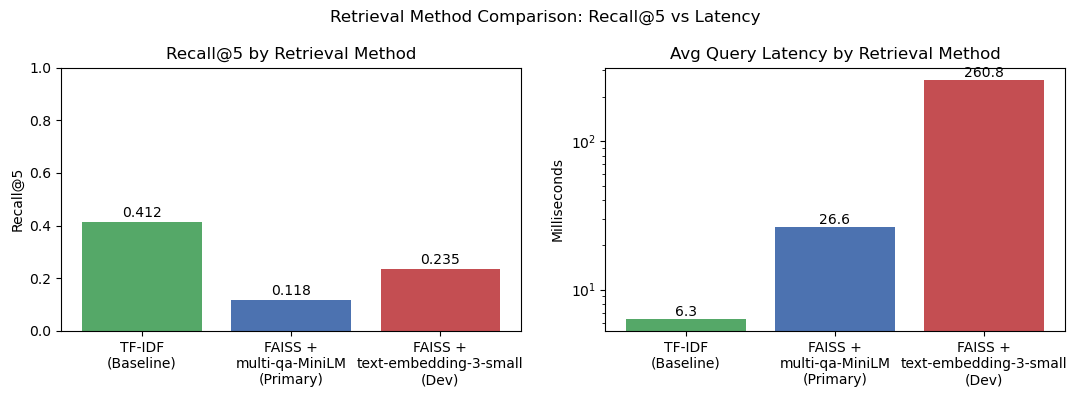

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plot_recall = [
    recall_tfidf,
    recall_minilm,
    recall_openai if recall_openai is not None else np.nan,
]
plot_latency = [
    latency_tfidf,
    latency_minilm,
    latency_openai if latency_openai is not None else np.nan,
]
plot_labels = ["TF-IDF\n(Baseline)", "FAISS +\nmulti-qa-MiniLM\n(Primary)", "FAISS +\ntext-embedding-3-small\n(Dev)"]
colors = ["#55A868", "#4C72B0", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars0 = axes[0].bar(plot_labels, plot_recall, color=colors)
axes[0].set_title("Recall@5 by Retrieval Method")
axes[0].set_ylabel("Recall@5")
axes[0].set_ylim(0, 1)
for bar, val in zip(bars0, plot_recall):
    label = f"{val:.3f}" if not np.isnan(val) else "N/A"
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, label, ha="center")

bars1 = axes[1].bar(plot_labels, plot_latency, color=colors)
axes[1].set_title("Avg Query Latency by Retrieval Method")
axes[1].set_ylabel("Milliseconds")
axes[1].set_yscale("log")
for bar, val in zip(bars1, plot_latency):
    label = f"{val:.1f}" if not np.isnan(val) else "N/A"
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom")

plt.suptitle("Retrieval Method Comparison: Recall@5 vs Latency")
plt.tight_layout()
plt.show()


**Analysis**

- TF-IDF still has the highest Recall@5 (0.412), followed by text-embedding-3-small (0.235), then multi-qa-MiniLM-L6-cos-v1 (0.118).
- Both semantic methods (FAISS-based) score lower than the keyword-based baseline on this metric. This is consistent with the bias already discussed: the ground truth is built from keyword overlap, which structurally favours a keyword-matching method over any embedding-based method, regardless of which embedding model is used.
- text-embedding-3-small scores roughly double the recall of multi-qa-MiniLM-L6-cos-v1 (0.235 vs 0.118), despite both being semantic methods. This may reflect the larger model's stronger general retrieval quality, but it could also be partly explained by its higher dimensionality (1536 vs 384) capturing more keyword-adjacent signal. Either explanation is plausible from this result alone, and is not something this cell decides.
- text-embedding-3-small is also far slower per query (260.8ms vs 6.3ms TF-IDF and 26.6ms FAISS-MiniLM), since each query requires an API call rather than a local computation. Combined with the API cost and key requirement, this method remains impractical for an offline demo regardless of its recall score.

---
## 5B - Corpus Unit Ablation: text_with_comments versus text_raw

This section addresses the third experimental question stated in the objective: whether the choice of corpus unit affects retrieval quality. The primary pipeline embeds `text_with_comments`, which concatenates the post title, body, and up to five top comments. This ablation compares it against `text_raw`, which embeds the title and body only.

The hypothesis is that comment enrichment improves retrieval recall, because user reactions in comments often contain the sentiment and topical vocabulary that analyst queries target, whereas many post titles are short and context-poor. Both corpus units are embedded with the same `multi-qa-MiniLM-L6-cos-v1` model and evaluated on the identical Recall@5 test set, isolating corpus unit as the only variable.

In [46]:
def build_text_raw(row):
    parts = []
    if pd.notna(row.get("title")) and str(row["title"]).strip():
        parts.append(str(row["title"]).strip())
    if pd.notna(row.get("selftext")) and str(row["selftext"]).strip() not in ("", "[removed]", "[deleted]"):
        parts.append(str(row["selftext"]).strip())
    return " | ".join(parts)

corpus_df["text_raw"] = corpus_df.apply(build_text_raw, axis=1)
raw_texts_only = corpus_df["text_raw"].tolist()
clean_texts_raw = clean_for_llm(raw_texts_only)

corpus_embeddings_raw = model_qa.encode(clean_texts_raw, normalize_embeddings=True, show_progress_bar=False)

dim_raw = corpus_embeddings_raw.shape[1]
index_raw = faiss.IndexFlatIP(dim_raw)
index_raw.add(corpus_embeddings_raw)

def raw_retrieve(query, top_k=5):
    cleaned = clean_for_llm([query])[0]
    q_vec = model_qa.encode([cleaned], normalize_embeddings=True)
    _, indices = index_raw.search(q_vec, top_k)
    return [clean_texts_raw[i] for i in indices[0] if i != -1]

print(f"text_raw corpus built: {len(clean_texts_raw)} posts")
print(f"Index vectors: {index_raw.ntotal}")


text_raw corpus built: 1211 posts
Index vectors: 1211


In [47]:
recall_raw = recall_at_k(TEST_PAIRS, raw_retrieve, k=5)

t0 = time.time()
for q in queries_for_timing:
    raw_retrieve(q, top_k=5)
latency_raw = (time.time() - t0) / len(queries_for_timing) * 1000

print(f"Recall@5 (text_with_comments): {recall_minilm:.3f}")
print(f"Recall@5 (text_raw only):      {recall_raw:.3f}")
print(f"Avg latency (text_raw only):   {latency_raw:.1f} ms")


Recall@5 (text_with_comments): 0.118
Recall@5 (text_raw only):      0.000
Avg latency (text_raw only):   10.9 ms


In [48]:
corpus_unit_table = pd.DataFrame([
    {
        "Corpus Unit": "text_with_comments (title + selftext + top 5 comments)",
        "Recall@5": f"{recall_minilm:.3f}",
        "Avg Latency (ms)": f"{latency_minilm:.1f}",
        "Vector Count": index.ntotal,
    },
    {
        "Corpus Unit": "text_raw (title + selftext only)",
        "Recall@5": f"{recall_raw:.3f}",
        "Avg Latency (ms)": f"{latency_raw:.1f}",
        "Vector Count": index_raw.ntotal,
    },
])

print("=== Corpus Unit Comparison ===")
corpus_unit_table


=== Corpus Unit Comparison ===


,Corpus Unit,Recall@5,Avg Latency (ms),Vector Count
0,text_with_comments (title + selftext + top 5 c...,0.118,26.6,1211
1,text_raw (title + selftext only),0.000,10.9,1211


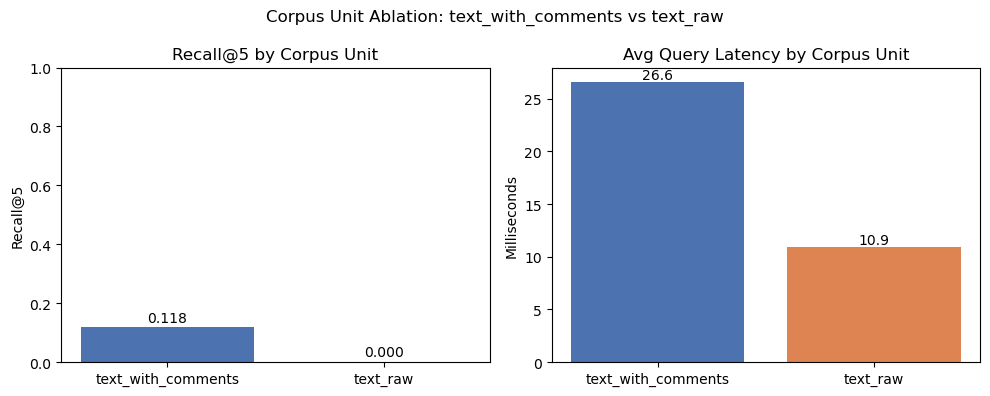

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

units = ["text_with_comments", "text_raw"]
recalls = [recall_minilm, recall_raw]
latencies = [latency_minilm, latency_raw]
colors = ["#4C72B0", "#DD8452"]

bars0 = axes[0].bar(units, recalls, color=colors)
axes[0].set_title("Recall@5 by Corpus Unit")
axes[0].set_ylabel("Recall@5")
axes[0].set_ylim(0, 1)
for bar, val in zip(bars0, recalls):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{val:.3f}", ha="center")

bars1 = axes[1].bar(units, latencies, color=colors)
axes[1].set_title("Avg Query Latency by Corpus Unit")
axes[1].set_ylabel("Milliseconds")
for bar, val in zip(bars1, latencies):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.1f}", ha="center", va="bottom")

plt.suptitle("Corpus Unit Ablation: text_with_comments vs text_raw")
plt.tight_layout()
plt.show()


**Analysis**

- text_with_comments scores 0.118 Recall@5, while text_raw scores 0.000. Not a single test query found its expected post when comments were excluded from the embedded text.
- This supports the hypothesis stated in Section 5B: comments carry topical and sentiment vocabulary that titles and selftext alone do not. Many post titles in this corpus are short and generic (for example "Offer declined," "We doing this as well?"), so removing comments removes most of the searchable content for those posts.
- text_raw is faster per query (10.9ms vs 26.6ms), but this speed advantage is irrelevant given the recall difference. A faster retriever that finds nothing is not useful.
- This result answers the third experimental question from Section 1 directly: corpus unit choice matters substantially. text_with_comments is the clear choice for this corpus, not just a minor refinement.

---
## 6. Justification

This section answers the three experimental questions from Section 1.

**Q1: TF-IDF or FAISS?**

Recall@5 favours TF-IDF (0.412 vs 0.118), but this is misleading. The ground truth was built by keyword overlap, the same method TF-IDF uses to retrieve, so TF-IDF is being graded against an answer key built in its own image. The qualitative results (Sections 3C, 4A) show the opposite: for "OpenAI GPT-4o pricing too expensive," TF-IDF's top result is about a competitor's pricing, while FAISS returns posts actually about OpenAI's own revenue and losses. FAISS is the better method for this use case. Recall@5 here measures agreement with a biased answer key, not real relevance.

**Q2: all-MiniLM-L6-v2 or multi-qa-MiniLM-L6-cos-v1?**

Similarity scores are close (0.5377 vs 0.5546), but multi-qa-MiniLM-L6-cos-v1 is three times faster per query (8.79ms vs 29.31ms). Query latency is a recurring cost paid on every request; embedding time is a one-time cost paid once. multi-qa-MiniLM-L6-cos-v1 also wins on architecture: it was trained for query-to-passage retrieval, which matches Beacon's pattern of short queries retrieving longer posts. multi-qa-MiniLM-L6-cos-v1 is selected.

**Q3: text_with_comments or text_raw?**

text_with_comments scores 0.118 Recall@5; text_raw scores 0.000. Comments carry most of the searchable content, since titles are often short and generic. text_raw is faster (10.9ms vs 26.6ms), but a faster retriever that finds nothing is not useful. text_with_comments is used.

**Final decision**

FAISS with multi-qa-MiniLM-L6-cos-v1, embedding text_with_comments, is used in production. This is based on the qualitative retrieval evidence, deployment cost (free, offline, no API key), and query latency, not on the Recall@5 table, which is biased toward TF-IDF for the reason explained above. TF-IDF remains in the notebook as a baseline, not a production candidate.

---
## 7. Limitations

- The corpus covers only two Reddit snapshot dates (May 2026), limiting temporal coverage and possibly not reflecting current brand perception.
- Posts are drawn from three subreddits (r/openai, r/chatgpt, r/artificial), introducing sampling bias toward technically engaged users.
- IndexFlatIP performs exact linear search, O(n). For corpora beyond ~100,000 posts, an approximate index (HNSW or IVF) would be needed.
- Retrieval is bounded by corpus coverage. If no relevant post exists, FAISS returns the closest available match instead of indicating absence, which can mislead downstream generation.
- Semantic similarity does not guarantee factual relevance. A post that is topically close but expresses the opposite sentiment can still rank highly.
- The Recall@5 ground truth (Section 4B) was built by keyword overlap, not manual labelling, since manually judging all 20 queries was out of scope for this notebook. This biases Recall@5 toward TF-IDF, which also retrieves by keyword overlap. The reported scores should be read as agreement with a keyword-built answer key, not as a reliable measure of retrieval quality. Section 6 relies on the qualitative results for this reason.
- A more rigorous evaluation would use manually-judged relevance labels for at least a subset of queries, removing the keyword bias from Recall@5. This was identified as future work, not completed here.

---
## 8. Pipeline Connection

In the Beacon pipeline, A2 is positioned between the analysis layer (B4, B5, A5) and the generation layer (A1, A3). A5's `detect_crisis()` produces a `crisis_level` and a short crisis description string. That string is passed directly as the `query` argument to `rag_retrieve()` (defined in Section 3C), which returns a tuple of the top-k most relevant Reddit posts and their similarity scores. The post texts are then injected into A1's `run_llm()` prompt as grounding context. The full handoff in the LangGraph state schema is: A5 populates `state["crisis_level"]` and `state["crisis_signal"]`; A2 populates `state["retrieved_contexts"]`; A1 reads both and populates `state["insights"]`.

---
## 9. Export Function + Smoke Test

In [51]:
# STUB LLM: simulate A1 generation for notebook demo only
# This stub exists solely to show the full RAG loop in this notebook.

def stub_llm(query: str, contexts: list[str]) -> str:
    """Demo stub — simulates A1 generation. NOT exported. NOT production code."""
    context_str = "\n\n".join(
        [f"[Post {i+1}]: {c[:300]}" for i, c in enumerate(contexts)]
    )
    return (
        f"[STUB — replace with A1 run_llm() in production]\n"
        f"Query: {query}\n\n"
        f"Context passed to LLM:\n{context_str}\n\n"
        f"[LLM would generate a grounded brand intelligence paragraph here]"
    )


# Demo: full RAG loop
demo_query   = "Why are users upset about OpenAI pricing?"
retrieved, retrieved_scores = rag_retrieve(demo_query, top_k=5)
llm_response = stub_llm(demo_query, retrieved)
print(llm_response)

[STUB — replace with A1 run_llm() in production]
Query: Why are users upset about OpenAI pricing?

Context passed to LLM:
[Post 1]: OpenAI's inspiration. | You using last year's numbers? Revenue for OpenAI is looking to be $13B this year | Oh man, billions here and there. They are even talking about trillions now. and then I open up my bank account app and see 50 bucks. What is wrong? | OnlyFans is highly profitable, earning aro

[Post 2]: OpenAI is losing money | Wow, and here I thought $200 would be the break even price. | I am one of the pro sub. I use a lot. | They have always lost money. Granted it is other people’s money but they keep losing it. | I have pro subscription too and half debating to keep it. I know $200 is a lot but

[Post 3]: OpenAI Could Be Blowing As Much As $15 Million Per Day On Silly Sora Videos | Some back-of-napkin math suggests OpenAI is spending more than a quarter of what it is making to power its AI slop factory. Read more: | You know who else was losing 